# Medical Chatbot Message Classification: LLM vs ML vs Hybrid

## Part one: Classification Using LLM

In [1]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")

print(train.shape, test.shape)
train.head()

(160, 3) (60, 2)


,id,requete,categorie
0,train_001,Rendez-vous pour le service ait,RDV
1,train_002,Je n'ai pas trouvé le service rhumatologie,Spécialités médicales
2,train_003,prendre un rendez-vous pour un scanner de la tête,RDV
3,train_004,Y'a il un service Odontologie ?,Spécialités médicales
4,train_005,Je voudrais payer un facture,Facturation


In [8]:
import matplotlib.pyplot as plt


train.shape



(160, 3)

In [9]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         160 non-null    object
 1   requete    160 non-null    object
 2   categorie  160 non-null    object
dtypes: object(3)
memory usage: 3.9+ KB


In [10]:

train.isnull().sum()

id           0
requete      0
categorie    0
dtype: int64

In [11]:
train.describe()

,id,requete,categorie
count,160,160,160
unique,160,160,4
top,train_001,Rendez-vous pour le service ait,RDV
freq,1,1,40


In [12]:
train["categorie"].value_counts()

categorie
RDV                      40
Spécialités médicales    40
Facturation              40
Coordonnées              40
Name: count, dtype: int64

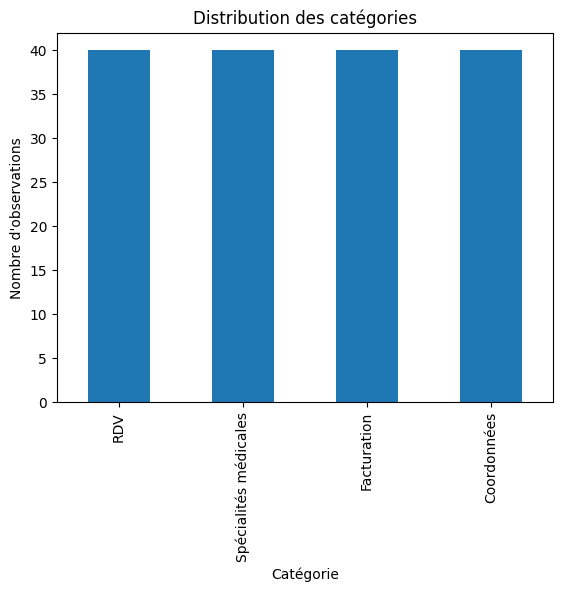

In [13]:
train["categorie"].value_counts().plot(kind="bar")

plt.title("Distribution des catégories")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'observations")
plt.show()

In [16]:
import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODELE = os.environ.get("GROQ_MODEL", "llama-3.1-8b-instant")

def appel_llm(prompt: str, temperature: float = 0.0, json_mode: bool = False) -> str:
    kwargs = {
        "model": MODELE,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": temperature,
    }
    if json_mode:
        kwargs["response_format"] = {"type": "json_object"}
    return client.chat.completions.create(**kwargs).choices[0].message.content

In [17]:


import json
from sklearn.metrics import classification_report


categories = sorted(train["categorie"].dropna().unique().tolist())
categories_str = ", ".join(categories)
print(categories_str)


def construire_prompt(message):
    return f"""
Tu es un classifieur de messages.

Ta tâche est de classer le message dans UNE SEULE des catégories suivantes :

{categories_str}

Règles :
- Choisis uniquement une catégorie parmi la liste.
- Analyse uniquement le contenu du message.
- Ne crée jamais de nouvelle catégorie.
- Retourne un score de confiance entre 0 et 1.
- 1 signifie que tu es très certain de la catégorie.
- 0 signifie que tu es très incertain.

Retourne UNIQUEMENT un objet JSON avec exactement ces deux champs :
{{
    "category": "nom_de_la_categorie",
    "confidence": 0.0
}}

Message à classifier :
{message}
"""


def classifier_message(message):
    prompt = construire_prompt(message)

    try:
        response = appel_llm(
            prompt,
            temperature=0.0,
            json_mode=True
        )

        result = json.loads(response)

        category = result.get("category")
        confidence = result.get("confidence")

        
        if category not in categories:
            return None, None

        
        confidence = float(confidence)

        if not 0 <= confidence <= 1:
            return None, None

        return category, confidence

    except Exception as e:
        print("Erreur :", e)
        return None, None


predictions = []
confidences = []

for message in train["requete"]:
    category, confidence = classifier_message(message)

    predictions.append(category)
    confidences.append(confidence)

train["prediction"] = predictions
train["confidence"] = confidences


y_true = train["categorie"]
y_pred = train["prediction"]



print(classification_report(
    y_true,
    y_pred
  
))

Coordonnées, Facturation, RDV, Spécialités médicales
                       precision    recall  f1-score   support

          Coordonnées       1.00      0.88      0.93        40
          Facturation       1.00      0.95      0.97        40
                  RDV       0.97      0.82      0.89        40
Spécialités médicales       0.74      0.97      0.84        40

             accuracy                           0.91       160
            macro avg       0.93      0.91      0.91       160
         weighted avg       0.93      0.91      0.91       160



In [18]:

predictions = []
confidences = []

for message in test["requete"]:
    category, confidence = classifier_message(message)

    predictions.append(category)
    confidences.append(confidence)

predictions_df = pd.DataFrame({
    "id": test["id"],
    "categorie": predictions,
    "confiance": confidences
})
predictions_df.to_csv("predictions_llm.csv", index=False)

## Part two: Classification Using ML

In [19]:

from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('french'))


def cleanning(text):
    text =text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return ' '.join(w for w in text.split() if w not in stop_words)


train['stm_text'] = train['requete'].apply(cleanning)



x= train['stm_text']
y=train['categorie']



X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
# Tes imports
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer,TfidfTransformer
from sklearn.linear_model import LogisticRegression

# Ton code
model=LogisticRegression()

pipe=Pipeline([('vect',CountVectorizer()),
                   ('tfidf',TfidfTransformer()),
                   ('clf',model)])
pipe.fit(X_train,y_train)

,steps,"[('vect', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


                       precision    recall  f1-score   support

          Coordonnées       0.78      0.88      0.82         8
          Facturation       1.00      0.62      0.77         8
                  RDV       0.86      0.75      0.80         8
Spécialités médicales       0.64      0.88      0.74         8

             accuracy                           0.78        32
            macro avg       0.82      0.78      0.78        32
         weighted avg       0.82      0.78      0.78        32



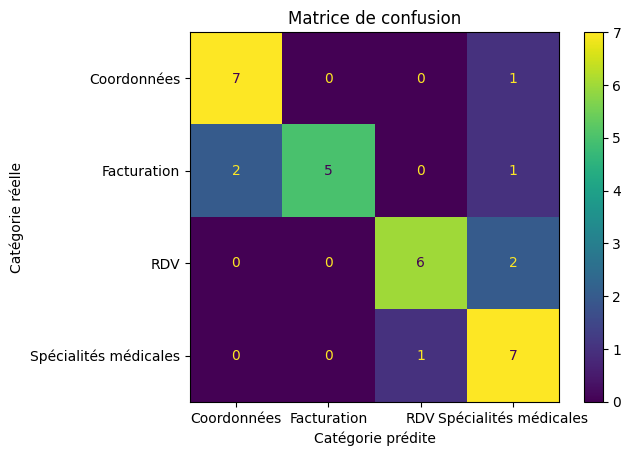

In [21]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred=pipe.predict(X_test)
print(classification_report(y_test,pred))

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipe.classes_
)

disp.plot()
plt.title("Matrice de confusion")
plt.xlabel("Catégorie prédite")
plt.ylabel("Catégorie réelle")
plt.show()

#Le F1-score et l'accuracy donnent la même importance à chaque catégorie. Puisque tous les messages ont la même importance, ils constituent des métriques pertinentes pour évaluer les performances du classifieur.

In [28]:
# Ton code
X_test = test["requete"].apply(cleanning)
pred=pipe.predict(X_test)
predictions_df = pd.DataFrame({
    "id": test["id"],
    "categorie": pred
})


predictions_df.to_csv("predictions_classifieur.csv", index=False)

In [23]:
import importlib.util

spec   = importlib.util.spec_from_file_location("scorer", "scorer.pyc")
scorer = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scorer)

print("=== LLM ===")
scorer.score("predictions_llm.csv")

print("=== Classifieur ===")
scorer.score("predictions_classifieur.csv")

=== LLM ===
  Accuracy : 0.967
  F1 macro : 0.967

                       precision    recall  f1-score   support

          Coordonnées       1.00      0.93      0.97        15
          Facturation       1.00      0.93      0.97        15
                  RDV       1.00      1.00      1.00        15
Spécialités médicales       0.88      1.00      0.94        15

             accuracy                           0.97        60
            macro avg       0.97      0.97      0.97        60
         weighted avg       0.97      0.97      0.97        60

=== Classifieur ===
  Accuracy : 0.850
  F1 macro : 0.852

                       precision    recall  f1-score   support

          Coordonnées       0.87      0.87      0.87        15
          Facturation       1.00      0.67      0.80        15
                  RDV       1.00      0.93      0.97        15
Spécialités médicales       0.67      0.93      0.78        15

             accuracy                           0.85        60
   

## Part three: Hybrid Methode

In [43]:
text = [
    "je veux un RDV",
    "Bonjour, je cherche un créneau pour une mammographie le mois prochain",
    "rdv ophtalmo urgent",
    "Je voudrais fixer une date pour une coloscopie",
    "chirurgie bariatrique",
    "Est-ce que l’hôpital dispose d’un service de médecine du sport ?",
    "Greffe de rein",
    "Où envoyer mon chèque pour la facture ?",
    "demande de remboursement d’un double paiement",
    "Combien coûte une IRM cérébrale sans prise en charge",
    "Quel est le numéro du service de radiologie ?",
    "Adresse mail du secrétariat de cardiologie",
    "Où se trouve le service des urgences ?",
]

for requete in text:
    pred1 = pipe.predict([requete])
    probabilities = pipe.predict_proba([requete])

    predicted_class_index = list(pipe.classes_).index(pred1[0])
    confidence = probabilities[0][predicted_class_index]

    print(f"Message : {requete}")
    if confidence > 0.5:
        print("Prédiction ml :", pred1[0])
        print("Probabilités :", dict(zip(pipe.classes_, probabilities[0].round(3))))
        print(f"Confiance : {confidence * 100:.2f}%")
    else:
        category, confidence = classifier_message(requete)
        print("Prédiction llm :", category)
        print(f"Confiance : {confidence * 100:.2f}%")
    print("-" * 50)

Message : je veux un RDV
Prédiction ml : RDV
Probabilités : {'Coordonnées': np.float64(0.149), 'Facturation': np.float64(0.173), 'RDV': np.float64(0.511), 'Spécialités médicales': np.float64(0.168)}
Confiance : 51.06%
--------------------------------------------------
Message : Bonjour, je cherche un créneau pour une mammographie le mois prochain
Prédiction llm : RDV
Confiance : 95.00%
--------------------------------------------------
Message : rdv ophtalmo urgent
Prédiction ml : RDV
Probabilités : {'Coordonnées': np.float64(0.11), 'Facturation': np.float64(0.133), 'RDV': np.float64(0.616), 'Spécialités médicales': np.float64(0.141)}
Confiance : 61.58%
--------------------------------------------------
Message : Je voudrais fixer une date pour une coloscopie
Prédiction llm : RDV
Confiance : 95.00%
--------------------------------------------------
Message : chirurgie bariatrique
Prédiction llm : Spécialités médicales
Confiance : 95.00%
-------------------------------------------------